Notebook 1 - Data Pipeline

In [28]:
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "data"


In [29]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)

START = '2005-01-01'
END   = '2025-01-01'
TICKERS = ['SPY', 'TLT', 'GLD', '^VIX']

SPY - S&P 500 ETF \
TLT - 20+ Year Treasury ETF \
GLD - Gold Futures ETF \
VIX - CBOE Volatility Index 

In [30]:
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
raw['Close'].to_csv(OUT / "raw" / "prices.csv")

[*********************100%***********************]  4 of 4 completed


In [31]:
raw.head()
raw.tail()
raw.shape
raw.isna().sum()

Price   Ticker
Close   GLD       0
        SPY       0
        TLT       0
        ^VIX      0
High    GLD       0
        SPY       0
        TLT       0
        ^VIX      0
Low     GLD       0
        SPY       0
        TLT       0
        ^VIX      0
Open    GLD       0
        SPY       0
        TLT       0
        ^VIX      0
Volume  GLD       0
        SPY       0
        TLT       0
        ^VIX      0
dtype: int64

In [32]:
prices = raw['Close'].copy()
prices = prices.rename(columns={'^VIX': 'VIX'})
prices = prices[['SPY', 'TLT', 'GLD', 'VIX']]
prices.head()

Ticker,SPY,TLT,GLD,VIX
Date,,,,
2005-01-03,81.383720,44.396461,43.020000,14.08
2005-01-04,80.389267,43.931202,42.740002,13.98
2005-01-05,79.834526,44.166321,42.669998,14.09
2005-01-06,80.240417,44.196369,42.150002,13.58
2005-01-07,80.125420,44.296448,41.840000,13.49


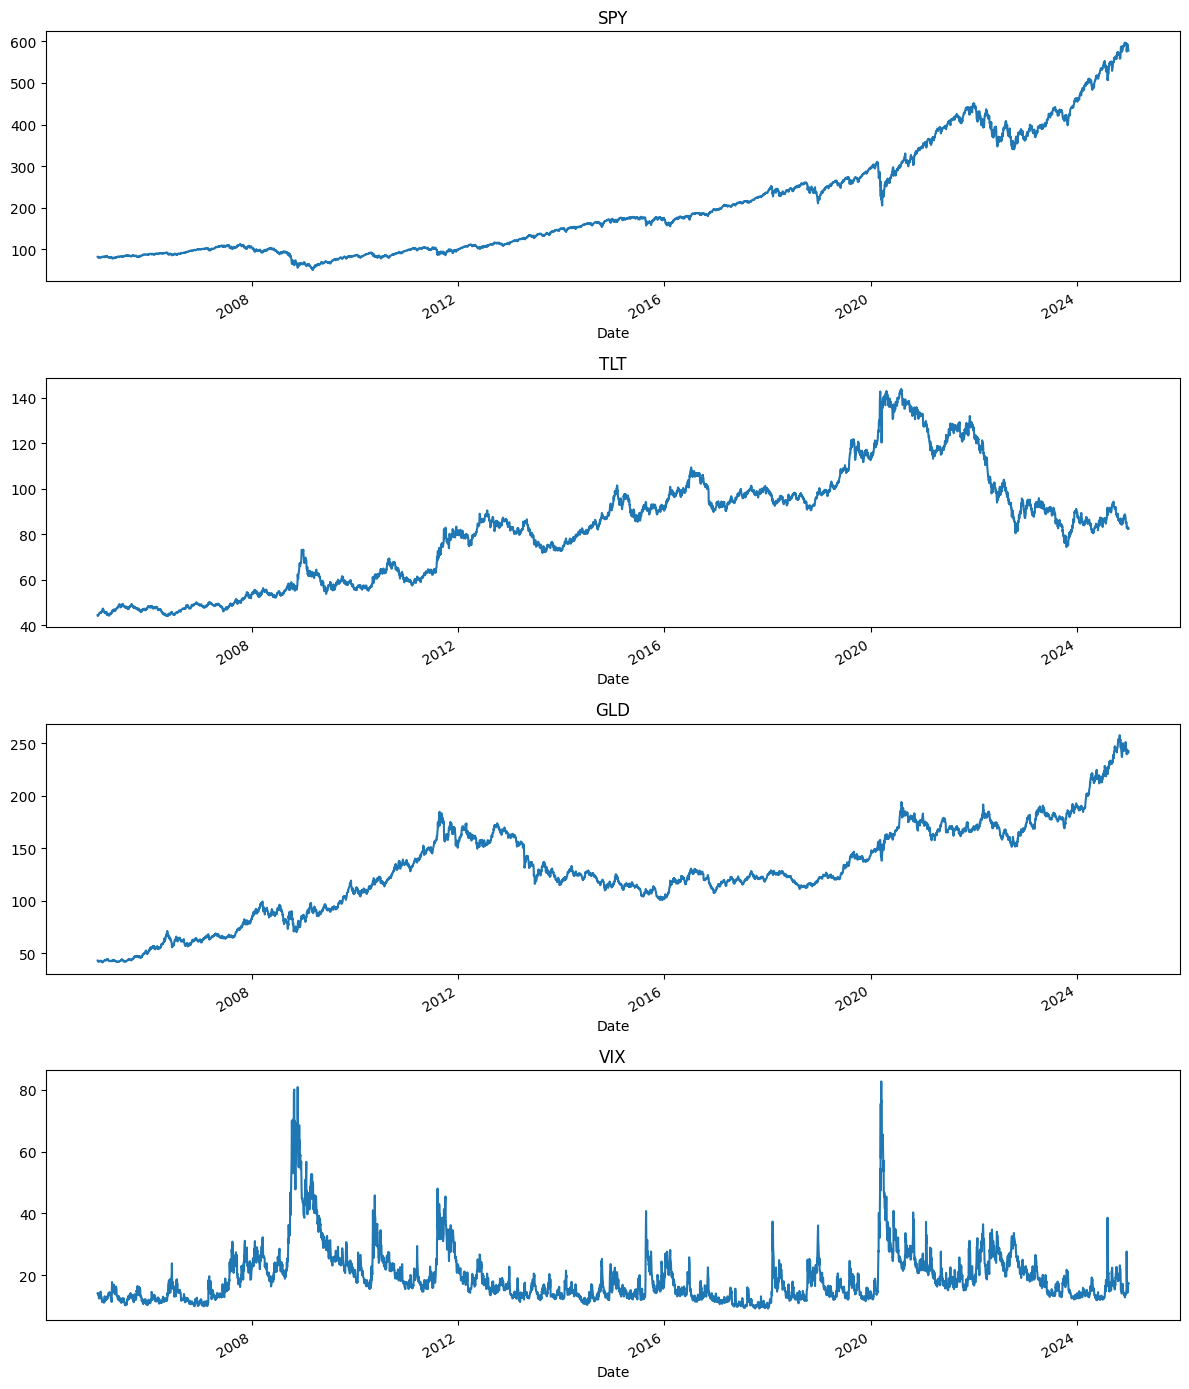

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=False)
for axis, col in zip(axes, prices.columns):
    prices[col].plot(ax=axis, title=col)
plt.tight_layout()


In [34]:
astprices = prices[['SPY', 'TLT', 'GLD']]

logrt = np.log(astprices / astprices.shift(1)) #rt = ln(Pt/Pt-1)
simplert = astprices.pct_change() #rt = (Pt - Pt-1)/Pt-1

vix = prices['VIX'] 

In [35]:
#Removing all the NaN rows formed from dividing by 0
logrt = logrt.dropna(how='all')
simplert = simplert.dropna(how='all')

In [36]:
logrt.describe()


Ticker,SPY,TLT,GLD
count,5032.000000,5032.000000,5032.000000
mean,0.000389,0.000123,0.000343
std,0.012005,0.009320,0.011064
min,-0.115887,-0.069010,-0.091905
25%,-0.003962,-0.005419,-0.005114
50%,0.000697,0.000439,0.000547
75%,0.005787,0.005561,0.006104
max,0.135578,0.072502,0.106974


In [37]:
simplert.describe()

Ticker,SPY,TLT,GLD
count,5032.000000,5032.000000,5032.000000
mean,0.000462,0.000166,0.000405
std,0.011991,0.009323,0.011052
min,-0.109424,-0.066683,-0.087808
25%,-0.003955,-0.005405,-0.005101
50%,0.000697,0.000440,0.000547
75%,0.005804,0.005576,0.006123
max,0.145198,0.075195,0.112905


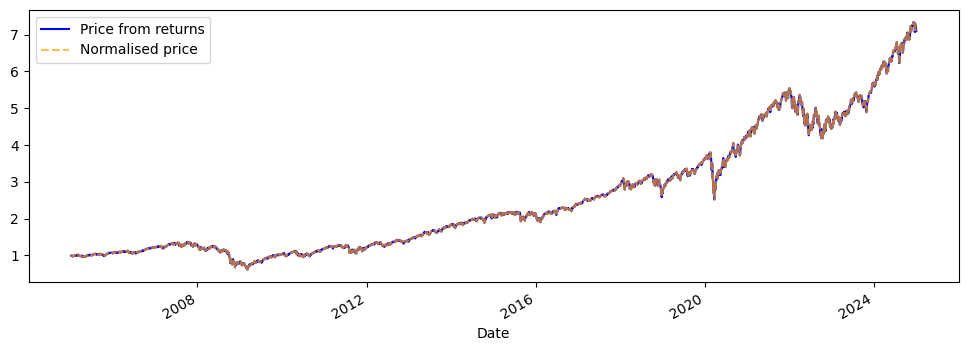

In [38]:
#Checking by recovering the prices from the simple returns

fig, axes = plt.subplots(figsize=(12, 4))

# Cumulative return starting at 1
cumret = (1 + simplert['SPY']).cumprod()
cumret.plot(ax=axes, label='Price from returns', color='blue')

# Price normalized to start at 1
normalized_price = prices['SPY'] / prices['SPY'].iloc[0]
normalized_price.plot(ax=axes, label='Normalised price', color='orange', linestyle='--', alpha=0.7)

axes.legend()
plt.show()

In [39]:
logrt.to_csv(OUT / "processed" / "logrt.csv")
simplert.to_csv(OUT / "processed" / "simplert.csv")
prices[["VIX"]].to_csv(OUT / "processed" / "vix.csv")
